In [1]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [30]:
%matplotlib inline

from Visualization import generalVisualization
from Visualization import gloveVisuals
from Visualization import visualHelpers
from Utilities import config

import pickle
import select_landmarks_MI
import importlib
import voltagemap
import setofpoints
import main
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import make_swiss_roll

In [3]:
importlib.reload(generalVisualization)
importlib.reload(gloveVisuals)
importlib.reload(visualHelpers)
importlib.reload(voltagemap)
importlib.reload(main)

<module 'main' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/main.py'>

In [6]:
def generate_swissroll_setofpoints(n_samples=1000, noise=0.0) -> setofpoints.SetOfPoints:
	"""
	Generates a Swiss roll dataset and returns it as a SetOfPoints instance.

	Args:
		n_samples (int): Number of data points to generate.
		noise (float): Standard deviation of Gaussian noise added to the data.

	Returns:
		SetOfPoints: An instance containing the Swiss roll points with uniform weights.
	"""
	points, _ = make_swiss_roll(n_samples=n_samples, noise=noise)
	return setofpoints.SetOfPoints(points)


In [8]:
centroids = generate_swissroll_setofpoints()

In [10]:
config.params['k']=2
config.params['r']=1

In [11]:
all_voltages = main.compute_voltages(centroids)

<class 'setofpoints.SetOfPoints'>


In [12]:
voltage_map = select_landmarks_MI.select_landmarks(all_voltages)

Adding landmark index=0 lm_index=225 with MI=0.3198
Adding landmark index=3 lm_index=563 with MI=0.5958
Adding landmark index=24 lm_index=243 with MI=0.8549
Adding landmark index=3 lm_index=906 with MI=1.1046
Adding landmark index=99 lm_index=617 with MI=1.3144
Adding landmark index=38 lm_index=963 with MI=1.5375
Adding landmark index=42 lm_index=666 with MI=1.8662
Adding landmark index=48 lm_index=900 with MI=2.1217
Adding landmark index=97 lm_index=825 with MI=2.2769
Adding landmark index=65 lm_index=635 with MI=2.4564


In [17]:
data_to_save = {"all_voltages": all_voltages, "voltage_map": voltage_map, "centroids": centroids}

In [18]:
with open('../../Voltage_Temp/Results/voltage_map.npy', 'wb') as f:
    pickle.dump(data_to_save, f)

In [19]:
with open('../../Voltage_Temp/Results/glove_voltage_map.npy', 'rb') as f:
    data_to_save = pickle.load(f)

In [20]:
voltage_map = voltagemap.VoltageMap()
for entry in data_to_save['voltage_map'].entries:
    voltage_map.add_solution(entry["landmark"], np.log(entry["voltages"]))

In [31]:
def plot_3d_voltage_colored(voltage_map, centroids):
    va = voltage_map.voltage_array()

    if centroids.shape[1] < 3:
        raise ValueError("Need at least 3 dimensions after transformation for 3D plot.")

    voltages = np.max(va, axis=1)  # or change to something else, like np.mean(va, axis=1)
    norm = plt.Normalize(vmin=np.min(voltages), vmax=np.max(voltages))
    colors = plt.cm.viridis(norm(voltages))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c=colors, s=20)

    ax.set_title("3D Voltage-Transformed Visualization")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.tight_layout()
    plt.show()

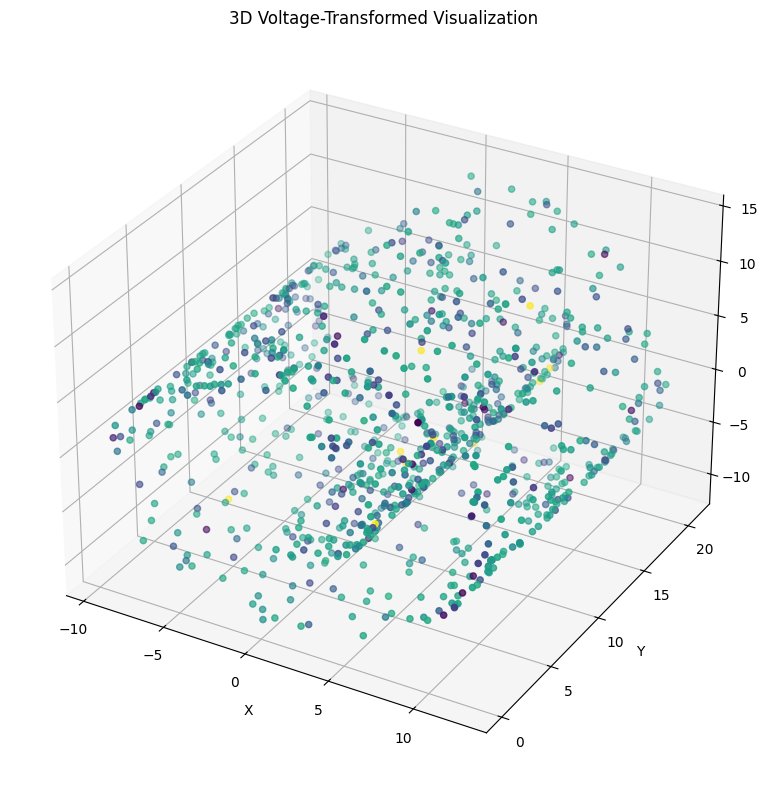

In [32]:
plot_3d_voltage_colored(voltage_map, centroids)